In [1]:
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torchsummary import summary
device = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/liperasz/anaconda3/envs/card-21/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /home/liperasz/anaconda3/envs/card-21/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
# transformando as imagens
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
    ])

In [3]:

# dados de treinno
trn_ds = MNIST('data/', transform=img_transform, train=True, download=False)
# dados de teste
val_ds = MNIST('data/', transform=img_transform, train=False, download=False)

batch_size = 256

# carregando com o data loader
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [4]:
# criando a classe do auto endoder
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # criando o encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, stride=1)
        )

        # decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2), nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 5, stride=3, padding=1), nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, 2, stride=2, padding=1), nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# innstanciando o encoder
model = ConvAutoEncoder().to(device)
# sumário do autoencoder
summary(model, torch.zeros(2, 1, 28, 28));

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 2, 2]            --
|    └─Conv2d: 2-1                       [-1, 32, 10, 10]          320
|    └─ReLU: 2-2                         [-1, 32, 10, 10]          --
|    └─MaxPool2d: 2-3                    [-1, 32, 5, 5]            --
|    └─Conv2d: 2-4                       [-1, 64, 3, 3]            18,496
|    └─ReLU: 2-5                         [-1, 64, 3, 3]            --
|    └─MaxPool2d: 2-6                    [-1, 64, 2, 2]            --
├─Sequential: 1-2                        [-1, 1, 28, 28]           --
|    └─ConvTranspose2d: 2-7              [-1, 32, 5, 5]            18,464
|    └─ReLU: 2-8                         [-1, 32, 5, 5]            --
|    └─ConvTranspose2d: 2-9              [-1, 16, 15, 15]          12,816
|    └─ReLU: 2-10                        [-1, 16, 15, 15]          --
|    └─ConvTranspose2d: 2-11             [-1, 1, 28, 28]           65
| 

In [5]:
# função para treinar o modelo
def train_batch(input, model, criterion, optimizer):
    model.train()
    optimizer.zero_grad()
    output = model(input)
    loss = criterion(output, input)
    loss.backward()
    optimizer.step()
    return loss

# função para validar o modelo
@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    output = model(input)
    loss = criterion(output, input)
    return loss

EPOCH: 1.000  val_loss: 0.368  trn_loss: 0.469  (14.85s - 59.39s remaining)
EPOCH: 2.000  val_loss: 0.240  trn_loss: 0.286  (26.10s - 39.15s remaining)
EPOCH: 3.000  val_loss: 0.112  trn_loss: 0.155  (38.20s - 25.47s remaining)
EPOCH: 4.000  val_loss: 0.090  trn_loss: 0.101  (49.18s - 12.29s remaining)
EPOCH: 5.000  val_loss: 0.081  trn_loss: 0.088  (59.76s - 0.00s remaining)


100%|██████████| 106/106 [00:00<00:00, 7024.52it/s]


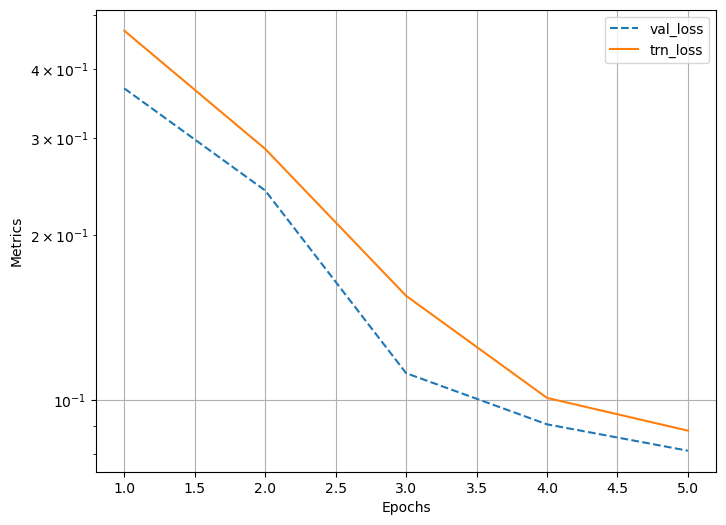

In [6]:
# instanciando modelo
model = ConvAutoEncoder().to(device)
# função de calculo de erro
criterion = nn.MSELoss()
# otimizador
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5
log = Report(num_epochs)

# realizar o treinamento e validação dos dados
for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
        loss = train_batch(data, model, criterion, optimizer)
        log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
        loss = validate_batch(data, model, criterion)
        log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    
    log.report_avgs(epoch+1)

log.plot_epochs(log=True)

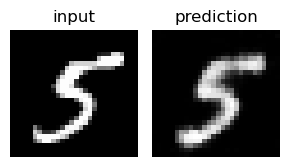

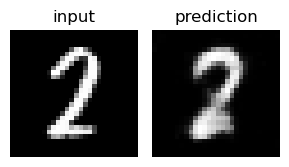

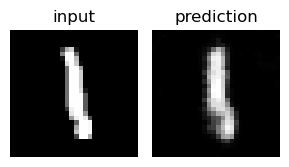

In [7]:
# loop para mostrar as respostas certas e o que foi previsto
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1, 2, figsize=(3, 3))
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()

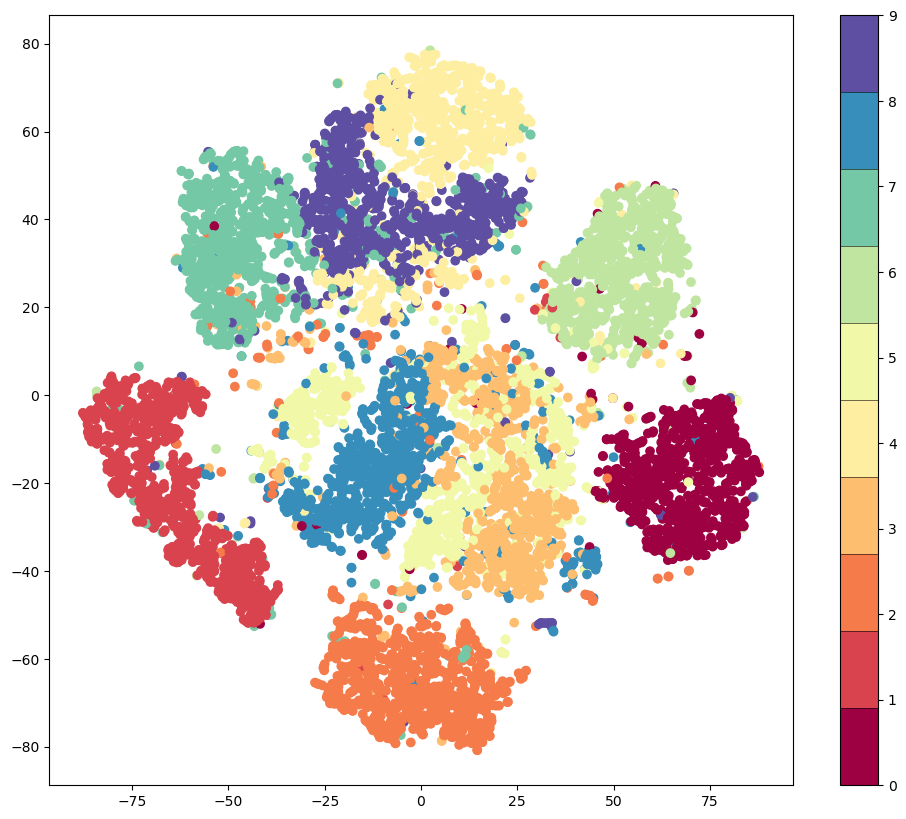

In [ ]:
latent_vectors = []
classes = []

for im, clss in val_dl:
    # passa a imagem pelo encoder
    latent_vectors.append(model.encoder(im).view(len(im), -1))
    classes.extend(clss)

# concatena a lista do tensor
latent_vectors = torch.cat(latent_vectors).cpu().detach().numpy()

# transforma o espaço em 2 dimensões
tsne = TSNE(2)
clustered = tsne.fit_transform(latent_vectors)

# plota o grafico
fig = plt.figure(figsize=(12, 10))
cmap = plt.get_cmap('Spectral', 10)
plt.scatter(*zip(*clustered), c=classes, cmap=cmap)
plt.colorbar(drawedges=True)

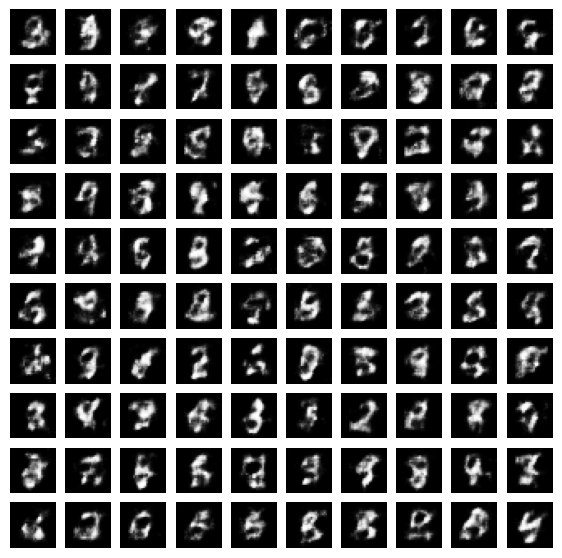

In [9]:
latent_vectors = []
classes = []

# passa as imagens pelo encoder para compacta-las
for im,clss in val_dl:
    latent_vectors.append(model.encoder(im))
    classes.extend(clss)
latent_vectors = torch.cat(latent_vectors).cpu().detach().numpy().reshape(10000, -1)

# calcula média e desvio padrão para cada dimensão
rand_vectors = []
for col in latent_vectors.transpose(1,0):
    mu, sigma = col.mean(), col.std()
    rand_vectors.append(sigma*torch.randn(1,100) + mu)

# passa pelo decoder, criando novamente imagens
rand_vectors = torch.cat(rand_vectors).transpose(1,0).to(device)
fig, ax = plt.subplots(10,10,figsize=(7,7)); ax = iter(ax.flat)
for p in rand_vectors:
    img = model.decoder(p.reshape(1,64,2,2)).view(28,28)
    show(img, ax=next(ax))